In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

Размер тренировочной выборки: 50000
Размер тестовой выборки: 10000


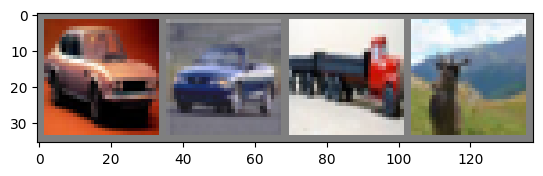

Метки: car car truck deer
Архитектура CNN модели:
CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
Начало обучения CNN...
Epoch [1/15], Loss: 1.4256, Accuracy: 48.04%
Epoch [2/15], Loss: 1.0088, Accuracy: 64.2%
Epoch [3/15], Loss: 0.816, Accuracy: 71.29%
Epoch [4/15], Loss: 0.6806, Accuracy: 76.2%
Epoch [5/15], Loss: 0.5643, Accuracy: 80.15%
Epoch [6/15], Loss: 0.461, Accuracy: 83.94%
Epoch

In [ ]:

# Преобразования для данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Загрузка тренировочной и тестовой выборок
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# Создание DataLoader для батчевой загрузки
batch_size = 128
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Названия классов CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Размер тренировочной выборки: {len(trainset)}")
print(f"Размер тестовой выборки: {len(testset)}")

def imshow(img):
    img = img / 2 + 0.5  # Денормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))
print('Метки:', ' '.join(f'{classes[labels[j]]}' for j in range(4)))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            # Первый сверточный блок
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Второй сверточный блок
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Третий сверточный блок
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 64 * 8 * 8)
        x = self.fc_layers(x)
        return x

model = CNNModel().to("cpu")
print("Архитектура CNN модели:")
print(model)

# Функция для вычисления точности
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    return 100 * correct / total

# Инициализация функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Переменные для хранения истории обучения
train_losses = []
train_accuracies = []

print("Начало обучения CNN...")
start_time = time.time()

# Цикл обучения
num_epochs = 15
for epoch in range(num_epochs):
    running_loss = 0.0
    running_accuracy = 0.0
    batches = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to("cpu"), labels.to("cpu")

        # Обнуление градиентов
        optimizer.zero_grad()

        # Прямой проход + обратное распространение + оптимизация
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)
        batches += 1

    # Вывод статистики после каждой эпохи
    epoch_loss = running_loss / batches
    epoch_accuracy = running_accuracy / batches
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {round(epoch_loss, 4)}, Accuracy: {round(epoch_accuracy, 2)}%')

end_time = time.time()
print(f'Обучение завершено за {round(end_time - start_time, 2)} секунд')

In [ ]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.to("cpu"), labels.to("cpu")
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, all_preds, all_labels

# Оценка модели
cnn_accuracy, cnn_preds, cnn_labels = evaluate_model(model, testloader)
print(f'Точность CNN на тестовой выборке: {round(cnn_accuracy, 2)}%')

class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = self.layers(x)
        return x

# Создание и обучение MLP модели
mlp_model = MLPModel().to("cpu")
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
mlp_criterion = nn.CrossEntropyLoss()

print("\nНачало обучения MLP...")
mlp_start_time = time.time()

mlp_train_losses = []
mlp_train_accuracies = []

for epoch in range(num_epochs):
    running_loss = 0.0
    running_accuracy = 0.0
    batches = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to("cpu"), labels.to("cpu")

        mlp_optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = mlp_criterion(outputs, labels)
        loss.backward()
        mlp_optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)
        batches += 1

    epoch_loss = running_loss / batches
    epoch_accuracy = running_accuracy / batches
    mlp_train_losses.append(epoch_loss)
    mlp_train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {round(epoch_loss, 4)}, Accuracy: {round(epoch_accuracy, 2)}%')

mlp_end_time = time.time()
print(f'Обучение MLP завершено за {round(mlp_end_time - mlp_start_time, 2)} секунд')

Точность CNN на тестовой выборке: 73.35%

Начало обучения MLP...
Epoch [1/15], Loss: 1.6304, Accuracy: 42.0%
Epoch [2/15], Loss: 1.4107, Accuracy: 50.22%
Epoch [3/15], Loss: 1.2967, Accuracy: 54.37%
Epoch [4/15], Loss: 1.2054, Accuracy: 57.23%
Epoch [5/15], Loss: 1.1181, Accuracy: 60.36%
Epoch [6/15], Loss: 1.0302, Accuracy: 63.55%
Epoch [7/15], Loss: 0.9601, Accuracy: 66.04%
Epoch [8/15], Loss: 0.8775, Accuracy: 68.94%
Epoch [9/15], Loss: 0.8026, Accuracy: 71.46%
Epoch [10/15], Loss: 0.7292, Accuracy: 74.13%
Epoch [11/15], Loss: 0.6609, Accuracy: 76.64%
Epoch [12/15], Loss: 0.5959, Accuracy: 78.8%
Epoch [13/15], Loss: 0.5452, Accuracy: 80.56%
Epoch [14/15], Loss: 0.4821, Accuracy: 83.1%
Epoch [15/15], Loss: 0.4402, Accuracy: 84.38%
Обучение MLP завершено за 374.83 секунд


Точность MLP на тестовой выборке: 53.31%


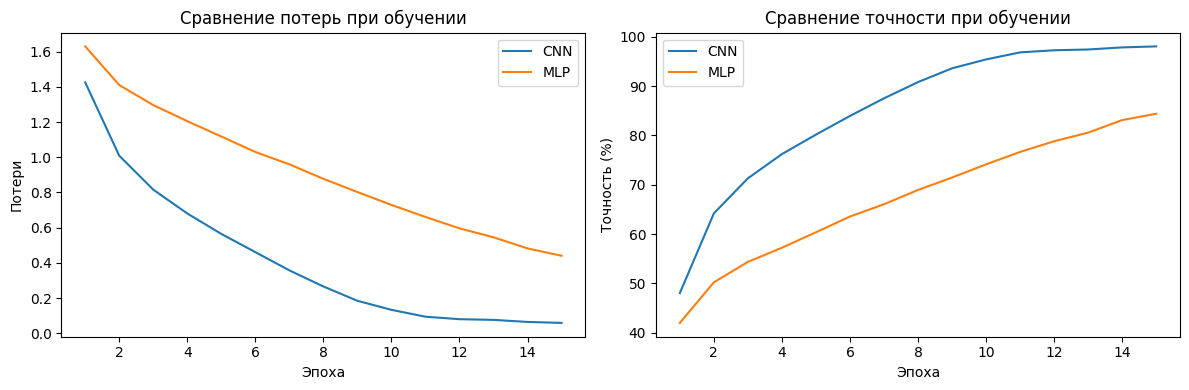

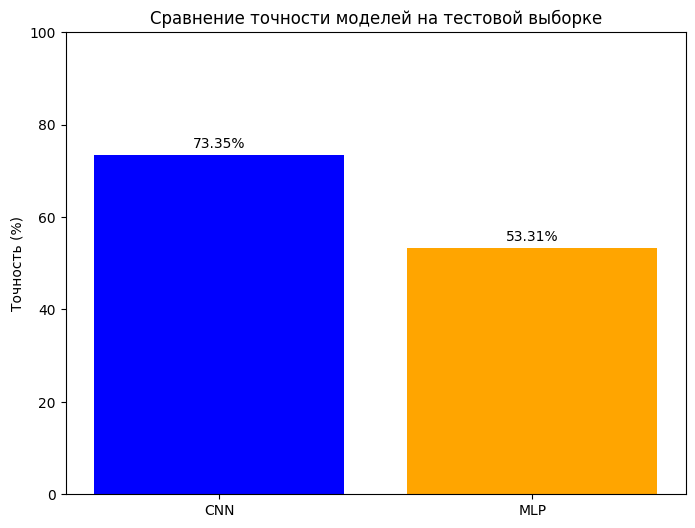

<Figure size 1000x800 with 0 Axes>

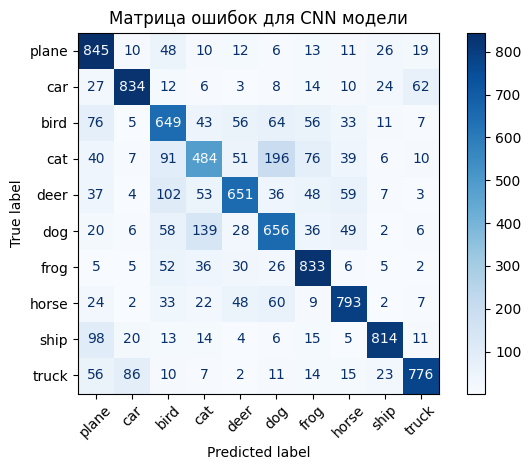

In [ ]:
# Оценка MLP модели
mlp_accuracy, mlp_preds, mlp_labels = evaluate_model(mlp_model, testloader)
print(f'Точность MLP на тестовой выборке: {round(mlp_accuracy, 2)}%')

# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='CNN')
plt.plot(range(1, num_epochs+1), mlp_train_losses, label='MLP')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('Сравнение потерь при обучении')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label='CNN')
plt.plot(range(1, num_epochs+1), mlp_train_accuracies, label='MLP')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Сравнение точности при обучении')
plt.legend()

plt.tight_layout()
plt.show()

# Сравнение итоговой точности
models = ['CNN', 'MLP']
accuracies = [cnn_accuracy, mlp_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Точность (%)')
plt.title('Сравнение точности моделей на тестовой выборке')
plt.ylim(0, 100)

# Добавление значений на столбцы
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{round(accuracy, 2)}%', ha='center', va='bottom')

plt.show()

# Матрица ошибок для CNN
cnn_cm = confusion_matrix(cnn_labels, cnn_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Матрица ошибок для CNN модели')
plt.tight_layout()
plt.show()


Оценка моделей с разными функциями активации...
Точность с LeakyReLU: 53.33%
Точность с GELU: 54.03%
Точность с Dropout: 49.26%
Точность с увеличенным количеством фильтров: 58.06%

Сводка результатов:
Базовая CNN          |  73.35%
MLP                  |  53.31%
LeakyReLU            |  53.33%
GELU                 |  54.03%
Dropout              |  49.26%
Больше фильтров      |  58.06%


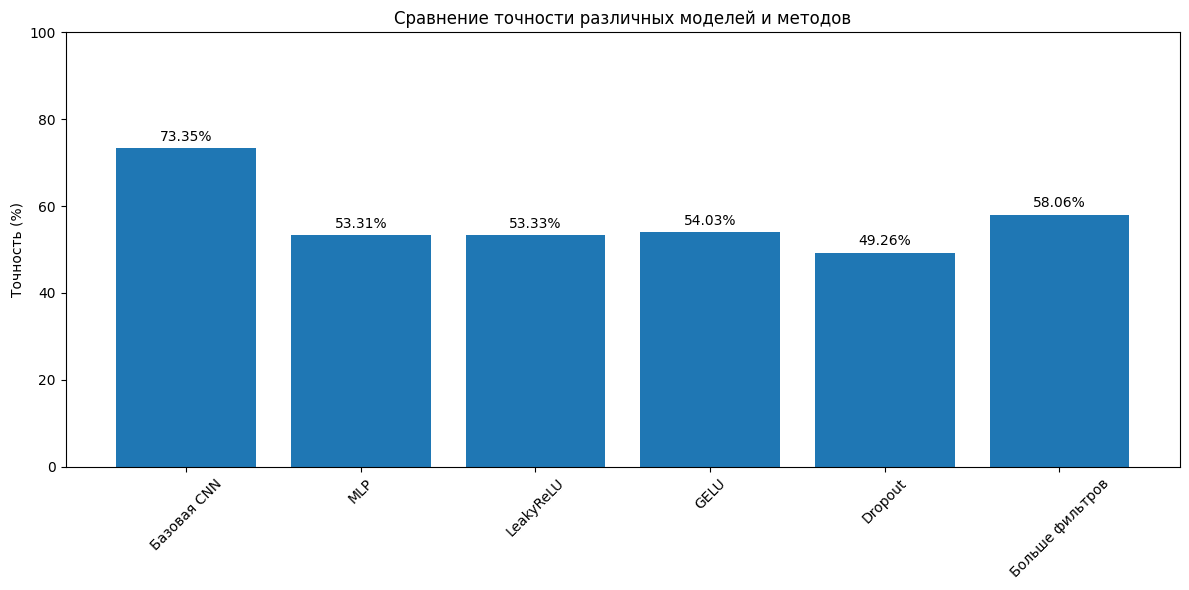

1. CNN (73.35%) значительно превосходит MLP (53.31%) на задаче CIFAR-10
2. Замена ReLU на LeakyReLU дала точность: 53.33%
3. Замена ReLU на GELU дала точность: 54.03%
4. Добавление Dropout: 49.26% (помогает против переобучения)
5. Увеличение фильтров: 58.06% (может улучшить качество)


In [ ]:
class CNNLeakyReLU(nn.Module):
    def __init__(self):
        super(CNNLeakyReLU, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.LeakyReLU(0.1)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 64 * 8 * 8)
        x = self.fc_layers(x)
        return x

class CNNGELU(nn.Module):
    def __init__(self):
        super(CNNGELU, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GELU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.GELU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 64 * 8 * 8)
        x = self.fc_layers(x)
        return x

# Быстрая оценка моделей с разными активациями
print("Оценка моделей с разными функциями активации...")

leaky_model = CNNLeakyReLU().to("cpu")
gelu_model = CNNGELU().to("cpu")

# Обучение на 5 эпохах для сравнения
def quick_train(model, model_name, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            if i > 50:  # Ограничим количество батчей для быстрого обучения
                break
            inputs, labels = data
            inputs, labels = inputs.to("cpu"), labels.to("cpu")

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    accuracy, _, _ = evaluate_model(model, testloader)
    return accuracy

leaky_accuracy = quick_train(leaky_model, "LeakyReLU")
gelu_accuracy = quick_train(gelu_model, "GELU")

print(f"Точность с LeakyReLU: {round(leaky_accuracy, 2)}%")
print(f"Точность с GELU: {round(gelu_accuracy, 2)}%")

class CNNDropout(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNNDropout, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 64 * 8 * 8)
        x = self.fc_layers(x)
        return x

dropout_model = CNNDropout().to("cpu")
dropout_accuracy = quick_train(dropout_model, "Dropout")

print(f"Точность с Dropout: {round(dropout_accuracy, 2)}%")

class CNNMoreFilters(nn.Module):
    def __init__(self):
        super(CNNMoreFilters, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),  # Увеличили с 32 до 64
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),  # Увеличили с 64 до 128
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1),  # Увеличили с 64 до 128
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512),  # Увеличили размер полносвязного слоя
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 128 * 8 * 8)
        x = self.fc_layers(x)
        return x

more_filters_model = CNNMoreFilters().to("cpu")
more_filters_accuracy = quick_train(more_filters_model, "More Filters")

print(f"Точность с увеличенным количеством фильтров: {round(more_filters_accuracy, 2)}%")

# Сводная таблица результатов
experiment_results = {
    'Модель': ['Базовая CNN', 'MLP', 'LeakyReLU', 'GELU', 'Dropout', 'Больше фильтров'],
    'Точность (%)': [cnn_accuracy, mlp_accuracy, leaky_accuracy, gelu_accuracy,
                    dropout_accuracy, more_filters_accuracy]
}

print("\nСводка результатов:")
for model, acc in zip(experiment_results['Модель'], experiment_results['Точность (%)']):
    print(f"{model:20} | {acc:6.2f}%")

# Визуализация сравнения всех моделей
plt.figure(figsize=(12, 6))
bars = plt.bar(experiment_results['Модель'], experiment_results['Точность (%)'])
plt.ylabel('Точность (%)')
plt.title('Сравнение точности различных моделей и методов')
plt.xticks(rotation=45)
plt.ylim(0, 100)

# Добавление значений на столбцы
for bar, accuracy in zip(bars, experiment_results['Точность (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{round(accuracy, 2)}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()
print(f"1. CNN ({round(cnn_accuracy, 2)}%) значительно превосходит MLP ({round(mlp_accuracy,2)}%) на задаче CIFAR-10")
print(f"2. Замена ReLU на LeakyReLU дала точность: {round(leaky_accuracy,2)}%")
print(f"3. Замена ReLU на GELU дала точность: {round(gelu_accuracy,2)}%")
print(f"4. Добавление Dropout: {round(dropout_accuracy, 2)}% (помогает против переобучения)")
print(f"5. Увеличение фильтров: {round(more_filters_accuracy,2)}% (может улучшить качество)")